In [1]:
%matplotlib widget

# Generate a 3D channel-like example

In [2]:
# Import libraries

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
import math
#from joblib import Parallel, delayed

from matplotlib.colors import LogNorm
L = LogNorm(vmin=1e-3, vmax=.1)
popts = {'norm': L}

import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

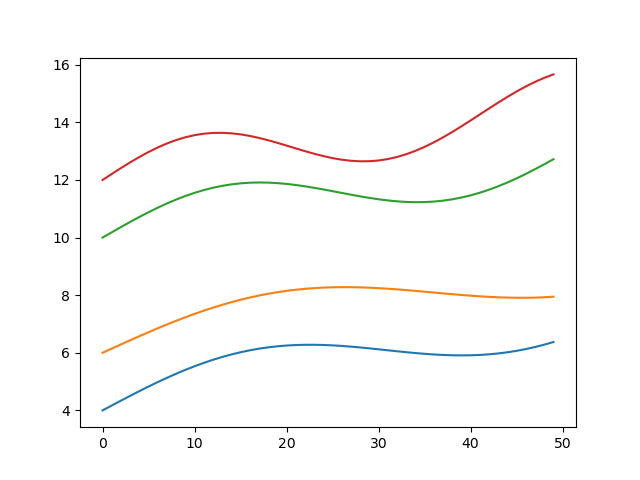

In [3]:
plt.figure()

x = np.linspace(0,60)

plt.plot(np.sin(x/12)+x/18+4)
plt.plot(np.sin(x/14)+x/21+6)

plt.plot(np.sin(x/10)+x/20+10)
plt.plot(np.sin(x/8)+x/22+12)



In [4]:

# In XY direction

x = np.linspace(0, 60, 60, endpoint=False)
y = np.linspace(0, 60, 60, endpoint=False)

xx = np.linspace(-10, 50, 60, endpoint=False)
yy = np.linspace(-10, 50, 60, endpoint=False)

X, Y = np.meshgrid(x, y) 

def cxy(x,y):

    ci = []
    
    xx = np.hstack(x)
    yy = np.hstack(y)

    for xi,yi in zip(xx,yy):

        if yi > (2*np.sin(xi/6)+xi/4+35):
            ci.append(1)

        elif yi > (1.5*np.sin(xi/4)+xi/5+30):
            ci.append(2)

        elif yi > (2*np.sin(xi/5)+xi/4.5+15):
            ci.append(3)

        elif yi > (1.5*np.sin(xi/6)+xi/6+12):
            ci.append(4)

        else:
            ci.append(1)
                   

    c = np.array(ci).reshape(np.shape(x))
    return c


cxy = cxy(X,Y)

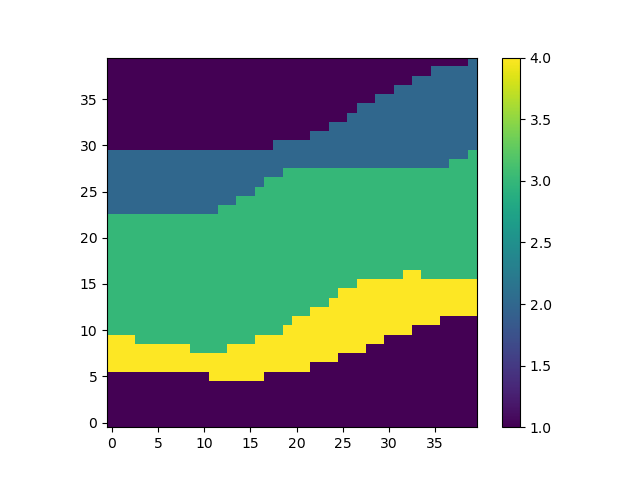

In [5]:
fig, ax = plt.subplots()
c = ax.imshow(cxy[10:50,10:50])
ax.invert_yaxis()
fig.colorbar(c)
plt.show()

In [6]:
cxy.shape

(60, 60)

In [7]:
# Create 2 layered models

#cxy = cxy.T
s_p = 10/1000
s_g = 100/1000
s_c = 50/1000
s_f = 30/1000

slope1 = 1/3
slope2 = -1/5

b1 = -1.2
b2 = +8

m = []

for i in range(cxy.shape[0]):
    for j in range(cxy.shape[1]):
        if cxy[i,j] == 3: # channel
            h = 3
            s1 = s_c
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 1: # plain
            h = 2
            s1 = s_p
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 4: # bars
            h = 2 + Y[i,j]/20 
            s1 = s_f
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 2: # bars
            h = 3.5 - Y[i,j]/40
            s1 = s_f
            s2 = s_g
            m.append([h, s1, s2])
            

In [8]:
m = np.array(m).reshape(60,60,3)

<Axes: >

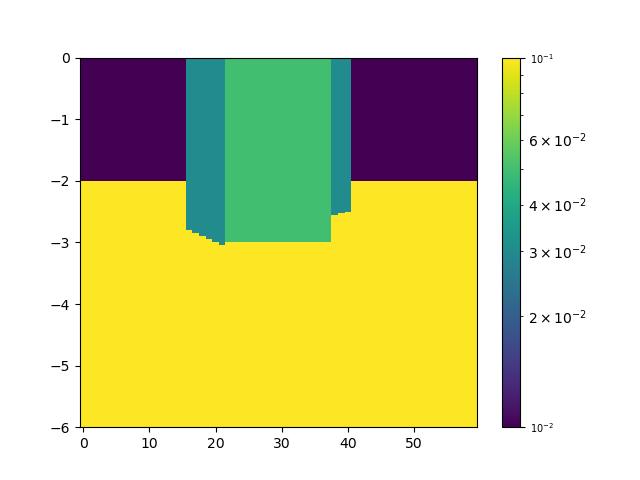

In [9]:
showStitchedModels(models = m[:,30,:], zMax= 6)

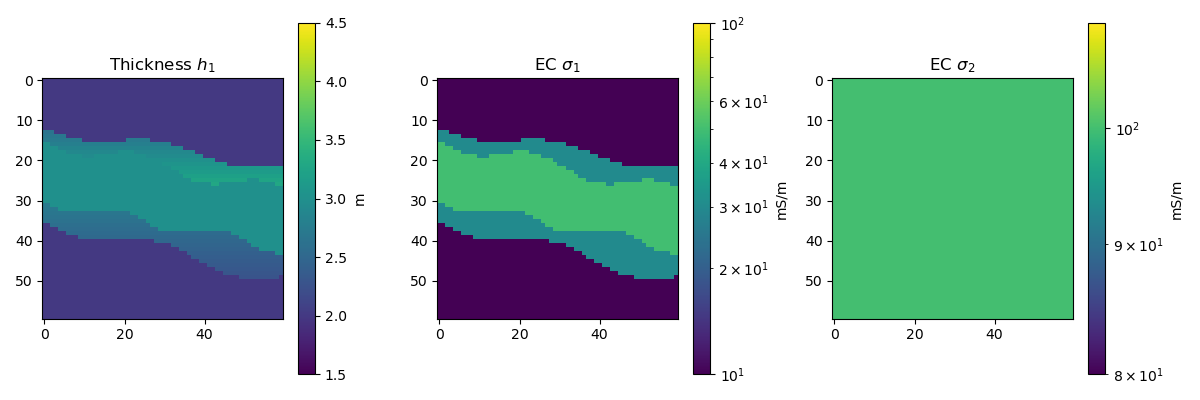

In [10]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0], vmin=1.5, vmax=4.5)
fig.colorbar(c1, ax=ax[0], label='m',)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1]*1000, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2]*1000, vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

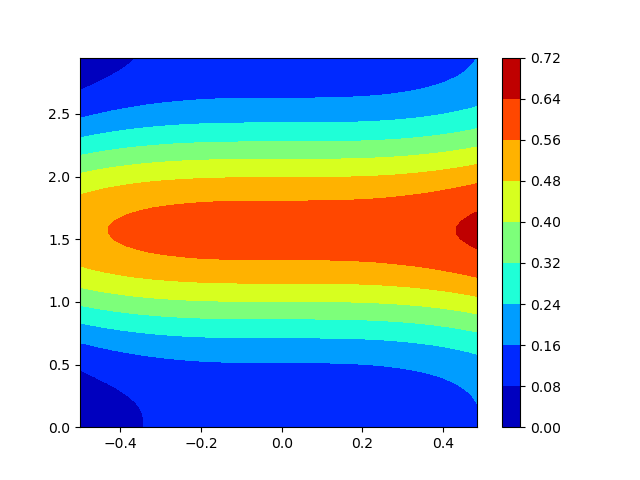

In [11]:
# Create a topography

x = np.linspace(-.5, .5, 61)
y = np.linspace(0, 3, 61)

X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots()

topo  = ((X**3  + np.sin(Y)**3 )/2  +.1)[:60,:60]
topo_ = ((X**3  + np.sin(Y)**3 )/2  +.1)[1:,1:]

c = ax.contourf(X[:-1,:-1], Y[:-1,:-1], topo, cmap = 'jet')
fig.colorbar(c, ax=ax)



Text(0.5, 1.0, 'Topography')

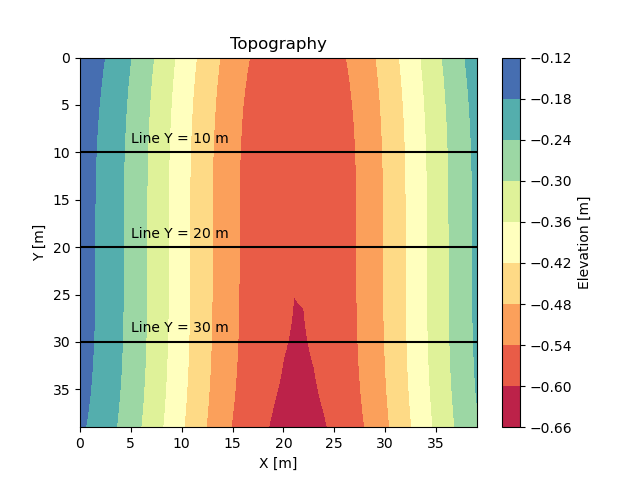

In [14]:
fig, ax = plt.subplots()

c=ax.contourf(-topo[10:50,10:50].T, cmap='Spectral')
fig.colorbar(c, ax=ax, label='Elevation [m]')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')

ax.plot([0,39], [10,10],'k')
ax.text(5,9, 'Line Y = 10 m')
ax.plot([0,39], [20,20],'k')
ax.text(5,19, 'Line Y = 20 m')
ax.plot([0,39], [30,30],'k')
ax.text(5,29, 'Line Y = 30 m')

ax.invert_yaxis()
ax.set_title('Topography')

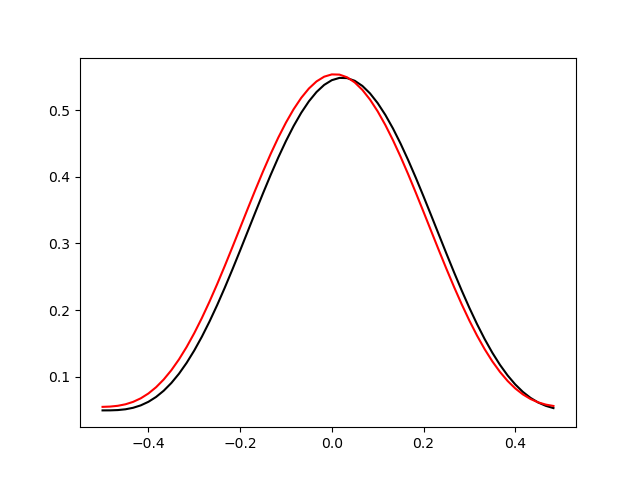

In [12]:
plt.figure()

plt.plot(X[0,:-1], topo[:,2], 'k')
plt.plot(X[0,:-1], topo_[:,2], 'r')

In [13]:
m_topo = []
s_a = 1/1e6 # sigma of air

for i in range(cxy.shape[0]):
    for j in range(cxy.shape[1]):
        if cxy[i,j] == 3: # channel
            h_a = topo[i,j] # air height
            h = 3
            s1 = s_c
            s2 = s_g
            m_topo.append([h_a, h, s_a, s1, s2])
        if cxy[i,j] == 1: # plain
            h_a = topo[i,j]
            h = 2
            s1 = s_p
            s2 = s_g
            m_topo.append([h_a, h, s_a, s1, s2])
        if cxy[i,j] == 4: # bars
            h_a = topo[i,j]
            h = 2 + Y[i,j]/20 
            s1 = s_f
            s2 = s_g
            m_topo.append([h_a, h, s_a, s1, s2])
        if cxy[i,j] == 2: # bars
            h_a = topo[i,j]
            h = 3.5 - Y[i,j]/40
            s1 = s_f
            s2 = s_g
            m_topo.append([h_a, h, s_a, s1, s2])
        
            

In [14]:
m_topo = np.array(m_topo).reshape(60,60,5)

<Axes: >

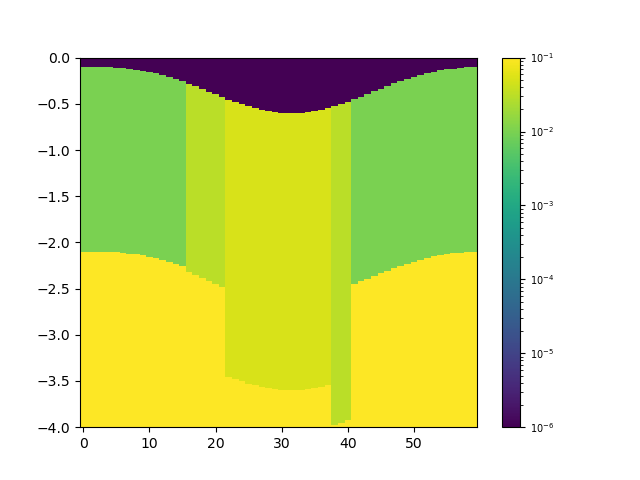

In [15]:
showStitchedModels(models = m_topo[:,30,:], zMax= 4,)

In [16]:
# Save model

np.save('models/model_3DChannel_topo', m_topo[10:50, 10:50, :])

In [17]:
np.save('models/model_3DChannel_topo_full.npy', m_topo)
np.save('models/topo.npy',topo)
np.save('models/topo_.npy',topo_)

In [18]:
m_topo.shape

(60, 60, 5)

# Populate 3D mesh

In [19]:
%%time

## 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# 1. Load model

# model with air layer

depths_air = -m_topo[:,:,0]
depths = np.stack((depths_air, -m_topo[:,:,0]-m_topo[:,:,1]), axis=2)

sigmas_1 = m_topo[:,:,3]
sigmas_2 = m_topo[:,:,4]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

src_x = 0
src_y = 0

# mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = [20/1000, 20/1000, sig_3d[0]],
                         center = [src_x, src_y, height],
                         mapping='Conductivity',
                         domain = ([-10, 50],[-10, 50],[-6,1]),
                         min_width_limits = [0.2, 0.2, 0.05], # changed z from 0.1 to 0.2
                         center_on_edge=False,
                         stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                         lambda_from_center=True,
                         lambda_factor=3, 
                         )

print(mesh)
# 3. Populate mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array
  
# Fill y-axis for y < 0

x = np.ones_like(mesh.cell_centers[:,0], dtype=bool)  
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0,0]) & (mesh.cell_centers[:,2] > depths[0,0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,0,1]) 

sig_x[x*y*z_lay1] = m_topo[0,0,3] # First layer sigma
sig_x[x*y*z_lay2] = m_topo[0,0,4] # Second layer sigma

# Fill internal positions

for i in range(len(xx)-1):
    for j in range(len(yy)-1):
   
        x = (mesh.cell_centers[:,0] >= xx[i]) & (mesh.cell_centers[:,0] < xx[i+1])
        y = (mesh.cell_centers[:,1] >= yy[j]) & (mesh.cell_centers[:,1] < yy[j+1])
        z_lay0 = (mesh.cell_centers[:,2] > depths[i,j,0])
        z_lay1 = (mesh.cell_centers[:,2] < depths[i,j,0]) & (mesh.cell_centers[:,2] > depths[i,j,1])
        z_lay2 = (mesh.cell_centers[:,2] < depths[i,j,1]) 

        sig_x[x*y*z_lay0] = m_topo[i,j,2]
        sig_x[x*y*z_lay1] = m_topo[i,j,3]
        sig_x[x*y*z_lay2] = m_topo[i,j,4]


#  4. Define models

Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')




  TensorMesh: 12,582,912 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    384   -106,075.79    141,471.28      0.20 35,355.50    1.33
   y    128   -105,409.52    120,405.40      0.20 39,634.49    1.49
   z    256       -834.26    106,306.73      0.05 17,493.39    1.20


CPU times: user 26min 5s, sys: 23.4 s, total: 26min 28s
Wall time: 26min 40s


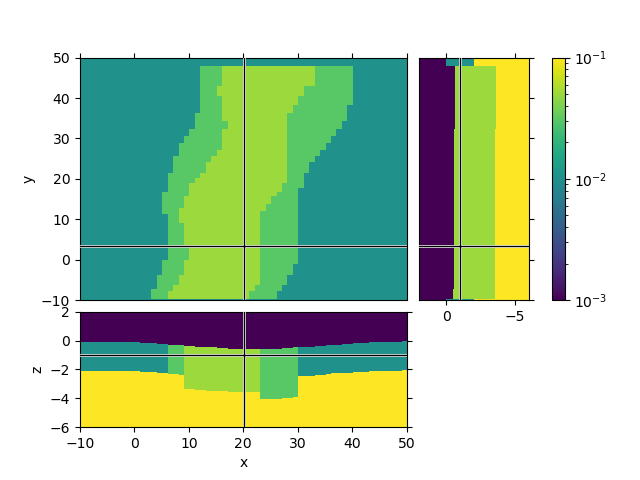

In [20]:

mesh.plot_3d_slicer(Model.property_x, zslice=-1, xlim=[-10,50], ylim = [-10,50], zlim=[-6,2], pcolor_opts= popts )


In [82]:
# Save model and mesh

In [89]:
survey = emg3d.surveys.Survey(sources = emg3d.TxElectricDipole([0,0,0,0,0]),
                     receivers= emg3d.RxElectricPoint([0,0,0,0,0]),
                     frequencies=9000)

In [90]:
Sim_Model = emg3d.Simulation(survey, Model, gridding='same')
Sim_Model_air = emg3d.Simulation(survey, Model_air, gridding='same')

In [91]:
Sim_Model.to_file('Sim_Model.h5')
Sim_Model_air.to_file('Sim_Model_air.h5')

In [92]:
Sim_Model = emg3d.load('Sim_Model.h5')
sim = Sim_Model['simulation']

Data loaded from «/palmyra/data/mecarrizomasca/LCI-EMI/Channel/Sim_Model.h5»
[emg3d v1.8.3.dev10+g6aee03e (format 1.0) on 2025-01-03T22:27:50.086081].


In [93]:
sim.model.grid

TensorMesh: 12,582,912 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    384   -106,075.79    141,471.28      0.20 35,355.50    1.33
   y    128   -105,409.52    120,405.40      0.20 39,634.49    1.49
   z    256       -834.26    106,306.73      0.05 17,493.39    1.20

In [94]:
Model = sim.model
mesh = sim.model.grid

In [95]:
Sim_Model_air = emg3d.load('Sim_Model_air.h5')
sim = Sim_Model_air['simulation']
sim.model.grid

Data loaded from «/palmyra/data/mecarrizomasca/LCI-EMI/Channel/Sim_Model_air.h5»
[emg3d v1.8.3.dev10+g6aee03e (format 1.0) on 2025-01-03T22:27:52.027999].


TensorMesh: 12,582,912 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    384   -106,075.79    141,471.28      0.20 35,355.50    1.33
   y    128   -105,409.52    120,405.40      0.20 39,634.49    1.49
   z    256       -834.26    106,306.73      0.05 17,493.39    1.20

In [96]:
Model_air = sim.model

In [97]:
# Functions forward with topography

def FDEM3D_topo(geom, model_sig, model_air, height = 0.3):
    """ Simulate Dualem842S in 3D """
    startTime = time.time()
    
    frequency = 9000 # Hertz

    src_x   = geom[0]
    src_z   = geom[1]
    src_y   = geom[2]
    rec2_x  = geom[3]
    rec2_z  = geom[4]
    rec21_x = geom[5]
    rec21_z = geom[6]
    rec4_x  = geom[7]
    rec4_z  = geom[8]
    rec41_x = geom[9]
    rec41_z = geom[10]
    rec8_x  = geom[11]
    rec8_z  = geom[12]
    rec81_x = geom[13]
    rec81_z = geom[14]
    alpha   = geom[15]
    
    # Define sources geometry
    # source = [x, y, z, azimuth, dip]
    Hsource_coords = [src_x, src_y, src_z, 0, 90 + math.degrees(alpha)]
    Vsource_coords = [src_x, src_y, src_z, 90, 0 + math.degrees(alpha)]
   # Psource_coords = Hsource_coords
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsource_coords)
    Vsource = emg3d.TxMagneticPoint(Vsource_coords)
   # Psource = emg3d.TxMagneticPoint(Psource_coords)

    # Define receivers
    Hrec2 = [rec2_x, src_y, rec2_z, 0, 90 + math.degrees(alpha)]
    Vrec2 = [rec2_x, src_y, rec2_z, 90, 0 + math.degrees(alpha)]
    Prec2 = [rec21_x, src_y, rec21_z, 0, 0 + math.degrees(alpha)]
    Prec2_p = [rec21_x, src_y, rec21_z, 0, 90 + math.degrees(alpha)]

    Hrec4 = [rec4_x, src_y, rec4_z, 0, 90 + math.degrees(alpha)]
    Vrec4 = [rec4_x, src_y, rec4_z, 90, 0 + math.degrees(alpha)]
    Prec4 = [rec41_x, src_y, rec41_z, 0, 0 + math.degrees(alpha)]
    Prec4_p = [rec41_x, src_y, rec41_z, 0, 90 + math.degrees(alpha)]

    Hrec8 = [rec8_x, src_y, rec8_z, 0, 90 + math.degrees(alpha)]
    Vrec8 = [rec8_x, src_y, rec8_z, 90, 0 + math.degrees(alpha)]
    Prec8 = [rec81_x, src_y, rec81_z, 0, 0 + math.degrees(alpha)]
    Prec8_p = [rec81_x, src_y, rec81_z, 0, 90 + math.degrees(alpha)]

    print('Hsource:', Hsource_coords)
    print('Vsource:', Vsource_coords)
    print('Hrec2:', Hrec2)
    print('Vrec2:', Vrec2)
    print('Prec2:', Prec2)
    print('Prec2_p:', Prec2_p)
    print('Hrec4:', Hrec4)
    print('Vrec4:', Vrec4)
    print('Prec4:', Prec4)
    print('Prec4_p:', Prec4_p)
    print('Hrec8:', Hrec8)
    print('Vrec8:', Vrec8)
    print('Prec8:', Prec8)
    print('Prec8_p:', Prec8_p)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = model_sig, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = model_sig, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = model_air, source = Vsource, frequency = frequency)
    
    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = model_sig, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec2 = Hfield_H.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec2_p = Hfield_H_p.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec2_s = H_Hrec2 - H_Hrec2_p

    # For total field Hsource
    H_Hrec4 = Hfield_H.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec4_p = Hfield_H_p.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec4_s = H_Hrec4 - H_Hrec4_p

    # For total field Hsource
    H_Hrec8 = Hfield_H.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec8_p = Hfield_H_p.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec8_s = H_Hrec8 - H_Hrec8_p
    
    # For total field Vsource
    H_Vrec2 = Hfield_V.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec2_p = Hfield_V_p.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec2_s = H_Vrec2 - H_Vrec2_p

    # For total field Vsource
    H_Vrec4 = Hfield_V.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec4_p = Hfield_V_p.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec4_s = H_Vrec4 - H_Vrec4_p

    # For total field Vsource
    H_Vrec8 = Hfield_V.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec8_p = Hfield_V_p.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec8_s = H_Vrec8 - H_Vrec8_p
    
    # For total field Psource
    H_Prec2 = Hfield_H.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec2_p_xz = Hfield_H_p.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec2_s = H_Prec2 - H_Prec2_p_xz
    # Primary field Psource in zz direction
    H_Prec2_p = Hfield_H_p.get_receiver(Prec2_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec4 = Hfield_H.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec4_p_xz = Hfield_H_p.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec4_s = H_Prec4 - H_Prec4_p_xz
    # Primary field Psource in zz direction
    H_Prec4_p = Hfield_H_p.get_receiver(Prec4_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec8 = Hfield_H.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec8_p_xz = Hfield_H_p.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec8_s = H_Prec8 - H_Prec8_p_xz
    # Primary field Psource in zz direction
    H_Prec8_p = Hfield_H_p.get_receiver(Prec8_p)*(2j * np.pi * frequency * mu_0) 
    
    # Calculate output components OP and IP
    print('getting output components')
    #OUT = []
    # Horizontal coplanar
    op_h2 = (H_Hrec2_s/H_Hrec2_p).imag.amp()
    ip_h2 = (H_Hrec2_s/H_Hrec2_p).real.amp()

    op_h4 = (H_Hrec4_s/H_Hrec4_p).imag.amp()
    ip_h4 = (H_Hrec4_s/H_Hrec4_p).real.amp()

    op_h8 = (H_Hrec8_s/H_Hrec8_p).imag.amp()
    ip_h8 = (H_Hrec8_s/H_Hrec8_p).real.amp()

    # Vertical coplanar
    op_v2 = (H_Vrec2_s/H_Vrec2_p).imag.amp()
    ip_v2 = (H_Vrec2_s/H_Vrec2_p).real.amp()

    op_v4 = (H_Vrec4_s/H_Vrec4_p).imag.amp()
    ip_v4 = (H_Vrec4_s/H_Vrec4_p).real.amp()

    op_v8 = (H_Vrec8_s/H_Vrec8_p).imag.amp()
    ip_v8 = (H_Vrec8_s/H_Vrec8_p).real.amp()
    
    # Perpendicular
    op_p2 = (H_Prec2_s/H_Prec2_p).imag.amp()
    ip_p2 = (H_Prec2_s/H_Prec2_p).real.amp()

    op_p4 = (H_Prec4_s/H_Prec4_p).imag.amp()
    ip_p4 = (H_Prec4_s/H_Prec4_p).real.amp()

    op_p8 = (H_Prec8_s/H_Prec8_p).imag.amp()
    ip_p8 = (H_Prec8_s/H_Prec8_p).real.amp()

    # src x pos | rec x pos | midpoint | data
    OUT = {'geom' : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
           'src_x' : np.ones(9)*src_x,
           'src_y' : np.ones(9)*src_y,
           'rec_x' : np.hstack((rec2_x, rec4_x, rec8_x, 
                                rec2_x, rec4_x, rec8_x, 
                                rec21_x, rec41_x, rec81_x)),
           'midpx' : np.hstack(( src_x + 1, src_x + 2, src_x + 4,
                                 src_x + 1, src_x + 2, src_x + 4,
                                 src_x + 1.05, src_x + 2.05, src_x + 4.05 )),
           'op' : np.hstack((op_h2, op_h4, op_h8, op_v2, op_v4, op_v8, op_p2, op_p4, op_p8)),
           'ip' : np.hstack((ip_h2, ip_h4, ip_h8, ip_v2, ip_v4, ip_v8, ip_p2, ip_p4, ip_p8)) 
          }

    OUT = pd.DataFrame(OUT)
    print(OUT)
               
    endTime = time.time()
    print('Done in', (endTime - startTime), 'seconds!')
    return OUT

def FDEM3D_line_topo(geom, depths=depths, model=Model, model_air=Model_air, frequency=9000, ):

    src_x = geom[0]
    src_z = geom[1]
    src_y = geom[2]
    
    sig_bg = 20/1000
    sig_air = 1/1e6

   # npos = len(model)

    # Define mesh
    mesh = emg3d.construct_mesh(frequency = frequency,
                             properties = [sig_bg, sig_bg, sig_air],
                             center = [src_x, 0, src_z],
                             mapping='Conductivity',
                             domain = ([src_x - 20, src_x + 20], [-10, 10], [src_z-6, src_z+4]),
                             min_width_limits = [0.2, 0.2, 0.05], # changed z from 0.1 to 0.2
                             center_on_edge=False,
                             stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1.1,1.5]}, 
                             lambda_from_center=True,
                             lambda_factor=3, 
                       #      cell_numbers=[512, 128, 128]
                       #      max_buffer = 300000,
                       #      min_width_pps = 5
                             )

    print('src x:', src_x)
    print('src z:', src_z)
    print('src y:', src_y)
    #print('rec x:', [rec2_x, rec21_x, rec4_x, rec41_x, rec8_x, rec81_x])
    #print('rec z:', [rec2_z, rec4_z, rec8_z])
    #print('alpha:', math.degrees(alpha))
    print(mesh)
    
    
    #  4. Define models
    
    Model = model.interpolate_to_grid(mesh)
    
    Model_air = emg3d.Model(mesh,
                         property_x = sig_air,
                         mapping = 'Conductivity')

    data_3D = FDEM3D_topo(geom, 
                          Model, 
                          Model_air)

    return data_3D, mesh, Model



In [98]:
# Define the source and receivers geometry

nrows = 60
h0 = 0.3 # height of instrument

xx = np.linspace(-9, 51, 60, endpoint=False)
yy = np.linspace(-9, 51, 60, endpoint=False)

xx_ = np.linspace(-10, 50, 60, endpoint=False)
yy_ = np.linspace(-10, 50, 60, endpoint=False)

geom = []

for r in range(nrows):

    dz = topo_[:,r] - topo[:,r]
    dx = xx_ - xx
    
    h0 = 0.3 # height of the midpoint 
    
    alphas = np.arctan(-dz/dx)
    
    mdp_z = -topo[:,r] + (h0 / np.cos(alphas))
    mdp_x = xx_ + h0 * np.sin(alphas)
    
    src_x = mdp_x * np.cos(alphas)  - 4
    src_z = mdp_z + (mdp_x - src_x)*np.sin(alphas)
    src_y = np.ones_like(src_x)* yy_[r]
    
    rec2_x = mdp_x * np.cos(alphas)  - 2
    rec2_z = mdp_z + (mdp_x - rec2_x)*np.sin(alphas)
    
    rec21_x = mdp_x * np.cos(alphas)  - 1.9
    rec21_z = mdp_z + (mdp_x - rec21_x)*np.sin(alphas)
    
    rec4_x = mdp_x.copy()
    rec4_z = mdp_z.copy()
    
    rec41_x = mdp_x * np.cos(alphas)  + 0.1
    rec41_z = mdp_z + (mdp_x - rec41_x)*np.sin(alphas)
    
    rec8_x = mdp_x * np.cos(alphas)  + 4
    rec8_z = mdp_z + (mdp_x - rec8_x)*np.sin(alphas)
    
    rec81_x = mdp_x * np.cos(alphas)  + 4.1
    rec81_z = mdp_z + (mdp_x - rec81_x)*np.sin(alphas)
    
    geom.append(np.array([src_x, src_z, src_y, rec2_x, rec2_z, rec21_x, rec21_z, 
                                   rec4_x, rec4_z, rec41_x, rec41_z,
                                   rec8_x, rec8_z, rec81_x, rec81_z, alphas]).T)

In [99]:
geom_full = np.array(geom).reshape(3600,16)

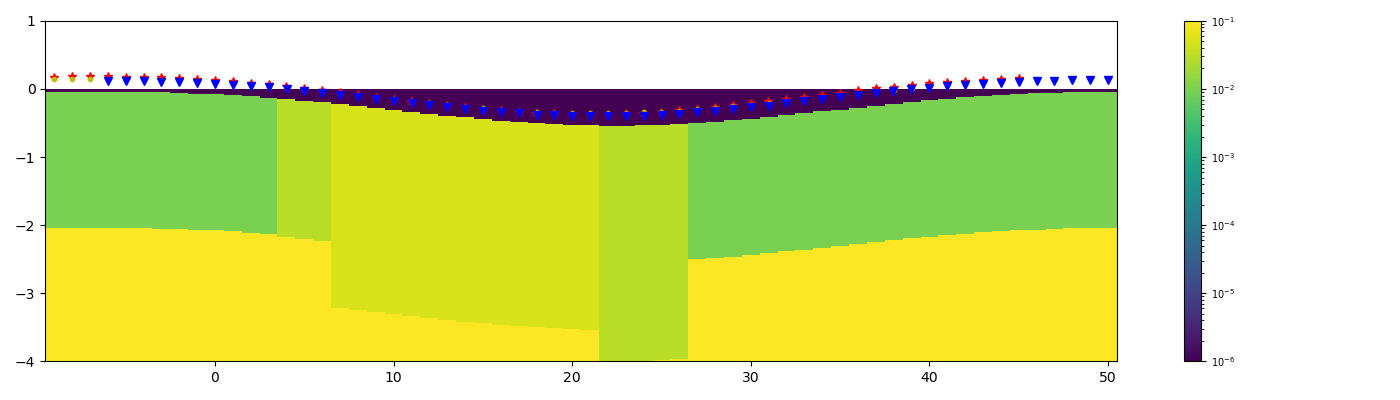

In [100]:


fig, ax = plt.subplots(figsize=(14,4))

n1 = -10
n2 = 50

showStitchedModels(m_topo[:,0,:], ax=ax, zMax=5, x=xx)

ax.set_ylim([-4, 1])
#ax.set_xlim([n1, n2])

plt.tight_layout()

for i in range(len(mdp_x[n1:n2])):
    ax.plot([src_x[n1:n2], mdp_x[n1:n2]], [src_z[n1:n2], mdp_z[n1:n2]], ':k')
    ax.plot([mdp_x[n1:n2], rec8_x[n1:n2]], [mdp_z[n1:n2], rec8_z[n1:n2]], ':k')

ax.plot(src_x, src_z, '*r')
ax.plot(mdp_x, mdp_z, '.y')
#ax.plot(rec2_x, rec2_z, '.r')
#ax.plot(rec4_x, rec4_z, '.b')
ax.plot(rec8_x, rec8_z, 'vb')

In [101]:
startTime = time.time()

n = 1000
data, mesh, Model = FDEM3D_line_topo(geom_full[n])
             
print()
endTime = time.time()
print('Done in', (endTime - startTime), 'seconds!')

src x: 25.98283144530161
src z: -0.27082525664024826
src y: 6.0

  TensorMesh: 2,949,120 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    320   -121,706.25    148,190.89      0.20 26,432.68    1.22
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z     96       -736.37    100,908.64      0.05 33,635.30    1.50


Hsource: [25.98283144530161, 6.0, -0.27082525664024826, 0, 88.55144788303326]
Vsource: [25.98283144530161, 6.0, -0.27082525664024826, 90, -1.4485521169667337]
Hrec2: [27.98283144530161, 6.0, -0.2202666353938494, 0, 88.55144788303326]
Vrec2: [27.98283144530161, 6.0, -0.2202666353938494, 90, -1.4485521169667337]
Prec2: [28.08283144530161, 6.0, -0.21773870433152942, 0, -1.4485521169667337]
Prec2_p: [28.08283144530161, 6.0, -0.21773870433152942, 0, 88.55144788303326]
Hrec4: [29.9924162068130

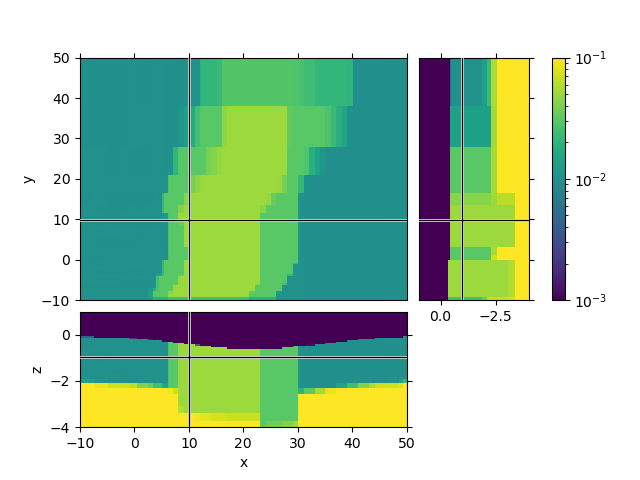

In [102]:
mesh.plot_3d_slicer(
    Model.property_x, xslice=10, yslice=10, zslice = -1, pcolor_opts=popts, xlim=[-10,50], ylim=[-10,50], zlim=[-4,1],
)

fig = plt.gcf()
ax = fig.get_children()
ax[1].plot(geom_full[n,11], geom_full[n,2], 'bv')
ax[1].plot(geom_full[n,7], geom_full[n,2], 'bv')
ax[1].plot(geom_full[n,3], geom_full[n,2], 'bv')

ax[2].plot(geom_full[n,11], geom_full[n,12], 'bv')
ax[2].plot(geom_full[n,7], geom_full[n,8], 'bv')
ax[2].plot(geom_full[n,3], geom_full[n,4], 'bv')

ax[3].plot(geom_full[n,12], geom_full[n,2], 'bv')
ax[3].plot(geom_full[n,8], geom_full[n,2], 'bv')
ax[3].plot(geom_full[n,4], geom_full[n,2], 'bv')

ax[1].plot(geom_full[n,0], geom_full[n,2], 'r*')
ax[2].plot(geom_full[n,0], geom_full[n,1], 'r*')
ax[3].plot(geom_full[n,1], geom_full[n,2], 'r*')

ax[1].plot([geom_full[n,0], geom_full[n,11]], [geom_full[n,2], geom_full[n,2]], ':')
ax[2].plot([geom_full[n,0], geom_full[n,11]], [geom_full[n,1], geom_full[n,12]], ':')
ax[3].plot([geom_full[n,1], geom_full[n,12]], [geom_full[n,2], geom_full[n,2]], ':')